In [ ]:
!which python
!pip freeze > requirements.txt

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src" / "data" / "SmartEM" / "Philips").exists():
    repo_root = repo_root.parents[2]

data_dir = repo_root / "src" / "data" / "SmartEM" / "Philips"

input_data = pd.read_csv(data_dir / "input.csv")
output_data = pd.read_csv(data_dir / "output.csv")

# input_data, output_data

# Visualisation

In [ ]:
input_data.nunique()
# input_data.info()
input_data.head()
input_data = input_data.loc[:, input_data.nunique() > 1]
# input_21 is degrees and should be converted to radians
# input_data.iloc[:, 21] = np.radians(input_data.iloc[:, 21])
# input_data.describe()
#input_20 is initial hair length
# input_14 is elevation angle is in degrees
# High 1 10
# Second High 11 3 9 2 4 6
# Third High 18 19 
input_data.nunique()
# Drop columns with only one unique value
input_data = input_data.loc[:, input_data.nunique() > 1]
input_data.nunique()
# input_data.head()
# Number of rows in input_data and output_data
# len(input_data), len(output_data)

# Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def preprocess_input(
    input_data,
    encodingHigh=0,
    categoricalEncodingHighType="one-hot",
    encodingMed=0,
    categoricalEncodingMedType="one-hot",
    encodingLow=0,
    categoricalEncodingLowType="one-hot",
    convertToRadians=0
):
    df = input_data.copy()

    # If nothing is enabled, return unchanged
    if (
        encodingHigh == 0 and
        encodingMed == 0 and
        encodingLow == 0 and
        convertToRadians == 0
    ):
        return df

    # Helper function
    def encode_columns(df, cols, encoding_type):
        cols = [col for col in cols if col in df.columns]

        if len(cols) == 0:
            return df

        if encoding_type is None:
            encoding_type = "one-hot"

        encoding_type = encoding_type.lower()

        if encoding_type == "one-hot":
            df = pd.get_dummies(df, columns=cols)

        elif encoding_type == "label":
            le = LabelEncoder()
            for col in cols:
                df[col] = le.fit_transform(df[col].astype(str))

        return df

    # High group
    if encodingHigh != 0:
        high_cols = ["input_10"]
        df = encode_columns(df, high_cols, categoricalEncodingHighType)

    # Medium group
    if encodingMed != 0:
        med_cols = [
            "input_2", "input_3", "input_4",
            "input_6", "input_8","input_9", "input_11",
            "input_10"
        ]
        df = encode_columns(df, med_cols, categoricalEncodingMedType)

    # Low group
    if encodingLow != 0:
        low_cols = ["input_18", "input_19"]
        df = encode_columns(df, low_cols, categoricalEncodingLowType)

    # Convert angles to radians
    if convertToRadians != 0:
        for col in ["input_14", "input_21"]:
            if col in df.columns:
                df[col] = np.deg2rad(df[col])
    return df

# Train Test Split

In [ ]:
import numpy as np

def trainTestSplit(processedInput, output, Train=10, Test=3, seed=42):
    # Unique values of input_1
    unique_vals = processedInput["input_1"].unique()

    # Check count
    if len(unique_vals) != Train + Test:
        raise ValueError(
            f"Found {len(unique_vals)} unique values in input_1, "
            f"but Train + Test = {Train + Test}"
        )

    # Shuffle with seed
    rng = np.random.RandomState(seed)
    shuffled_vals = unique_vals.copy()
    rng.shuffle(shuffled_vals)

    # Split
    TrainVals = shuffled_vals[:Train]
    TestVals = shuffled_vals[Train:]

    # Create train and test sets
    input_train = processedInput[processedInput["input_1"].isin(TrainVals)].copy()
    input_test = processedInput[processedInput["input_1"].isin(TestVals)].copy()
    output_train = output[processedInput["input_1"].isin(TrainVals)].copy()
    output_test = output[processedInput["input_1"].isin(TestVals)].copy()

    # Drop input_1 after splitting
    input_train = input_train.drop(columns=["input_1"])
    input_test = input_test.drop(columns=["input_1"])

    return input_train, input_test,output_train,output_test, TrainVals, TestVals


input_data.nunique()
# Drop columns with only one unique value
input_data = input_data.loc[:, input_data.nunique() > 1]
input_data.nunique()

processed_input = preprocess_input(input_data, encodingHigh=1, categoricalEncodingHighType="one-hot", encodingMed=1, categoricalEncodingMedType="one-hot", encodingLow=1, categoricalEncodingLowType="one-hot", convertToRadians=1)
input_train, input_test,output_train,output_test, TrainVals, TestVals = trainTestSplit(processedInput=processed_input, output=output_data, Train=10, Test=3, seed=42)
input_train.head()


# TabPFN
Does not work. Licensed tool. Not paying for this.

In [ ]:
# from tabpfn import TabPFNClassifier, TabPFNRegressor

# # clf = TabPFNClassifier()
# # clf.fit(input_train, output_data)  # downloads checkpoint on first use
# # predictions = clf.predict(input_test)

# reg = TabPFNRegressor()
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# predictions = reg.predict(input_test)

# Tree Models Initialisation

In [ ]:
from sklearn.model_selection import train_test_split # Function to split data into training and testing sets
import numpy as np


from xgboost import XGBRegressor

def train_xgboost(X_train, y_train):
    model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True,
    verbosity=2
)

    model.fit(X_train, y_train, verbose=True)
    return model

from lightgbm import LGBMRegressor
def train_lightgbm(X_train, y_train):
    model = LGBMRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    return model

from catboost import CatBoostRegressor
def train_catboost(X_train, y_train, categorical_columns=None):
    model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        random_seed=42,
        verbose=10
    )

    model.fit(
        X_train,
        y_train,
        cat_features=categorical_columns
    )

    return model

In [ ]:
output_data.head()

# Training on Output_1

In [ ]:
# X_train = Xtrain[0]
# y_train = Ytrain[0]["output_1"]
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# input_train, input_test,output_train,output_test, TrainVals, TestVals 
xgb_model = train_xgboost(input_train, output_train["output_1"])
lgb_model = train_lightgbm(input_train, output_train["output_1"])
cat_model = train_catboost(input_train, output_train["output_1"])

# Testing

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
xgb_pred = xgb_model.predict(input_test)
lgb_pred = lgb_model.predict(input_test)
cat_pred = cat_model.predict(input_test)

y_true = output_test["output_1"].values

# Metrics
models = {
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}

r2_scores = []
mae_scores = []
rmse_scores = []

for name, pred in models.items():
    r2_scores.append(r2_score(y_true, pred))
    mae_scores.append(mean_absolute_error(y_true, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_true, pred)))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(models.keys(), r2_scores)
axes[0].set_title("R² Score")
axes[0].set_ylabel("Higher is better")

axes[1].bar(models.keys(), mae_scores)
axes[1].set_title("MAE")
axes[1].set_ylabel("Lower is better")

axes[2].bar(models.keys(), rmse_scores)
axes[2].set_title("RMSE")
axes[2].set_ylabel("Lower is better")

plt.tight_layout()
plt.show()


# Scatter plot: true vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_true, pred, alpha=0.7)

    # ideal line
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(name)
    ax.set_xlabel("True output_1")
    ax.set_ylabel("Predicted output_1")

plt.tight_layout()
plt.show()

# Training Output 2

In [ ]:
# Training on Output_1
# X_train = Xtrain[0]
# y_train = Ytrain[0]["output_1"]
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# input_train, input_test,output_train,output_test, TrainVals, TestVals 
xgb_model = train_xgboost(input_train, output_train["output_2"])
lgb_model = train_lightgbm(input_train, output_train["output_2"])
cat_model = train_catboost(input_train, output_train["output_2"])

# Testing Output 2

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
xgb_pred = xgb_model.predict(input_test)
lgb_pred = lgb_model.predict(input_test)
cat_pred = cat_model.predict(input_test)

y_true = output_test["output_2"].values

# Metrics
models = {
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}

r2_scores = []
mae_scores = []
rmse_scores = []

for name, pred in models.items():
    r2_scores.append(r2_score(y_true, pred))
    mae_scores.append(mean_absolute_error(y_true, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_true, pred)))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(models.keys(), r2_scores)
axes[0].set_title("R² Score")
axes[0].set_ylabel("Higher is better")

axes[1].bar(models.keys(), mae_scores)
axes[1].set_title("MAE")
axes[1].set_ylabel("Lower is better")

axes[2].bar(models.keys(), rmse_scores)
axes[2].set_title("RMSE")
axes[2].set_ylabel("Lower is better")

plt.tight_layout()
plt.show()


# Scatter plot: true vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_true, pred, alpha=0.7)

    # ideal line
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(name)
    ax.set_xlabel("True output_2")
    ax.set_ylabel("Predicted output_2")

plt.tight_layout()
plt.show()

# Training Output 3

In [ ]:
# Training on Output_1
# X_train = Xtrain[0]
# y_train = Ytrain[0]["output_1"]
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# input_train, input_test,output_train,output_test, TrainVals, TestVals 
xgb_model = train_xgboost(input_train, output_train["output_3"])
lgb_model = train_lightgbm(input_train, output_train["output_3"])
cat_model = train_catboost(input_train, output_train["output_3"])

# Testing Output 3

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
xgb_pred = xgb_model.predict(input_test)
lgb_pred = lgb_model.predict(input_test)
cat_pred = cat_model.predict(input_test)

y_true = output_test["output_3"].values

# Metrics
models = {
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}

r2_scores = []
mae_scores = []
rmse_scores = []

for name, pred in models.items():
    r2_scores.append(r2_score(y_true, pred))
    mae_scores.append(mean_absolute_error(y_true, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_true, pred)))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(models.keys(), r2_scores)
axes[0].set_title("R² Score")
axes[0].set_ylabel("Higher is better")

axes[1].bar(models.keys(), mae_scores)
axes[1].set_title("MAE")
axes[1].set_ylabel("Lower is better")

axes[2].bar(models.keys(), rmse_scores)
axes[2].set_title("RMSE")
axes[2].set_ylabel("Lower is better")

plt.tight_layout()
plt.show()


# Scatter plot: true vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_true, pred, alpha=0.7)

    # ideal line
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(name)
    ax.set_xlabel("True output_3")
    ax.set_ylabel("Predicted output_3")

plt.tight_layout()
plt.show()

# Auto Gluon

In [ ]:
!pip install -U pip
!pip install -U setuptools wheel
!pip install autogluon

# Import Data

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src" / "data" / "SmartEM" / "Philips").exists():
    repo_root = repo_root.parents[2]

data_dir = repo_root / "src" / "data" / "SmartEM" / "Philips"

input_data = pd.read_csv(data_dir / "input.csv")
output_data = pd.read_csv(data_dir / "output.csv")

# Train Test Split
Apparently AutoGluon does not need pre processing

In [3]:
import numpy as np

def trainTestSplit(processedInput, output, Train=10, Test=3, seed=42):
    # Unique values of input_1
    unique_vals = processedInput["input_1"].unique()

    # Check count
    if len(unique_vals) != Train + Test:
        raise ValueError(
            f"Found {len(unique_vals)} unique values in input_1, "
            f"but Train + Test = {Train + Test}"
        )

    # Shuffle with seed
    rng = np.random.RandomState(seed)
    shuffled_vals = unique_vals.copy()
    rng.shuffle(shuffled_vals)

    # Split
    TrainVals = shuffled_vals[:Train]
    TestVals = shuffled_vals[Train:]

    # Create train and test sets
    input_train = processedInput[processedInput["input_1"].isin(TrainVals)].copy()
    input_test = processedInput[processedInput["input_1"].isin(TestVals)].copy()
    output_train = output[processedInput["input_1"].isin(TrainVals)].copy()
    output_test = output[processedInput["input_1"].isin(TestVals)].copy()

    # Drop input_1 after splitting
    input_train = input_train.drop(columns=["input_1"])
    input_test = input_test.drop(columns=["input_1"])

    return input_train, input_test,output_train,output_test, TrainVals, TestVals



input_train, input_test,output_train,output_test, TrainVals, TestVals = trainTestSplit(processedInput=input_data, output=output_data, Train=10, Test=3, seed=42)
input_train.head()


,input_2,input_3,input_4,input_5,input_6,input_7,input_8,input_9,input_10,input_11,...,input_13,input_14,input_15,input_16,input_17,input_18,input_19,input_20,input_21,input_22
0,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,...,9,62.311333,150,2100,250,-12.950,-1.136,930.932365,326.904678,21.103807
1,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,...,9,55.742061,150,2100,250,-12.239,-4.382,1082.927137,153.042818,13.931269
2,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,...,9,67.942716,150,2100,250,-10.024,8.277,984.849277,38.213696,18.031709
3,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,...,9,45.419135,150,2100,250,-11.168,6.654,983.234347,357.832140,11.502451
4,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,...,9,61.599897,150,2100,250,-12.991,0.487,704.864190,204.853589,20.680040


# Dataset Wrapper
Not required, but it is a way to standardise inputs to autogluon

In [11]:
from autogluon.tabular import TabularDataset
input_train_data = TabularDataset(input_train)
output_train_data = TabularDataset(output_train)
input_test_data = TabularDataset(input_test)
output_test_data = TabularDataset(output_test)

# Train

In [ ]:
from autogluon.tabular import TabularPredictor

predictors = {}
ag_args_fit = {"num_gpus": 1}

hyperparameters = {
    "CAT": {
        "task_type": "GPU",
        "devices": "0",
        "ag_args_fit": ag_args_fit
    }
}
itr=0
# Need to train one model per output
for col in output_train.columns:
    # combine input + one output
    train_data = input_train.copy()
    train_data[col] = output_train[col]
    train_data = TabularDataset(train_data)
    print(f"Training predictor for {col}...")
    # train one predictor per output
    # predictors[col] = TabularPredictor(label=col).fit(train_data)
    probType=["binary", "regression", "regression"]
    predictor = TabularPredictor(label=col).fit(
        train_data,
        presets="extreme",
        num_gpus=1,
        hyperparameters=hyperparameters,
        num_bag_folds=0,
        problem_type=probType[itr]
    )
    itr += 1

No path specified. Models will be saved in: "AutogluonModels/ag-20260423_124540"
Preset alias specified: 'extreme' maps to 'extreme_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.14
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #52-Ubuntu SMP PREEMPT_DYNAMIC Thu Dec  5 13:09:44 UTC 2024
CPU Count:          20
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 5.67/5.67 GB
Total GPU Memory:   Free: 5.67 GB, Allocated: 0.00 GB, Total: 5.67 GB
GPU Count:          1
Memory Avail:       10.96 GB / 30.98 GB (35.4%)
Disk Space Avail:   276.57 GB / 368.99 GB (75.0%)
Presets specified: ['extreme']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=0, num_bag_sets=1


Training predictor for output_1...


Beginning AutoGluon training ... Time limit = 3600s
AutoGluon will save models to "/home/sa1/Documents/gitReps/pythonQuickAndDirty/src/scripts/SmartEM/AutogluonModels/ag-20260423_124540"
Train Data Rows:    32723
Train Data Columns: 21
Label Column:       output_1
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.float64(1.0), np.float64(0.0)]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11235.65 MB
	Train Data (Original)  Memory Usage: 13.99 MB (0.1% of available memory)
	Inferring data type of each fe

Training predictor for output_2...


Problem Type:       multiclass
Preprocessing data ...
Fraction of data from classes with at least 10 examples that will be kept for training models: 0.9985025822815756
Train Data Class Count: 27
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11291.73 MB
	Train Data (Original)  Memory Usage: 13.96 MB (0.1% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 2 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDupl

Training predictor for output_3...


Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11277.58 MB
	Train Data (Original)  Memory Usage: 13.99 MB (0.1% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 2 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Useless Original Features (Count: 5): ['input_12', 'input_13', 'input_15', 'input_16', 'input_17']
		These features carry no predictive signal and should be manually in

# Test

In [ ]:
predictor3 = TabularPredictor.load("/home/sa1/Documents/gitReps/pythonQuickAndDirty/src/scripts/SmartEM/AutogluonModels/ag-20260423_124824")
predictor2 = TabularPredictor.load("/home/sa1/Documents/gitReps/pythonQuickAndDirty/src/scripts/SmartEM/AutogluonModels/ag-20260423_124650")
predictor1 = TabularPredictor.load("/home/sa1/Documents/gitReps/pythonQuickAndDirty/src/scripts/SmartEM/AutogluonModels/ag-20260423_124540")

# predictor1.info()
predictors = {
    "output_1": predictor1,
    "output_2": predictor2,
    "output_3": predictor3
}

for col, predictor in predictors.items():
    y_pred = predictor.predict(input_test)

# Plots

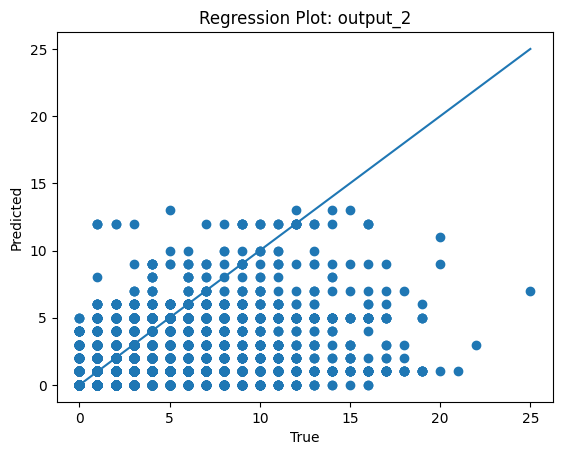

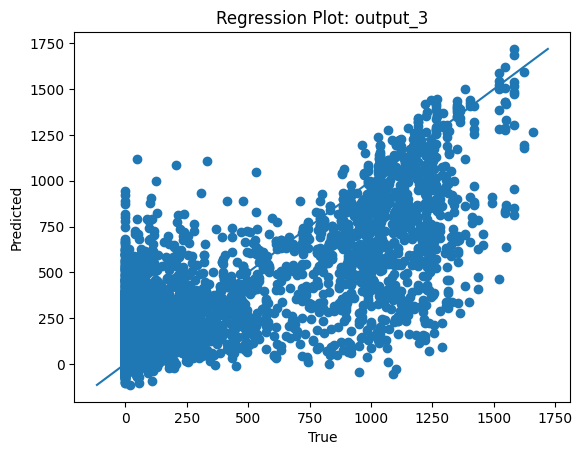

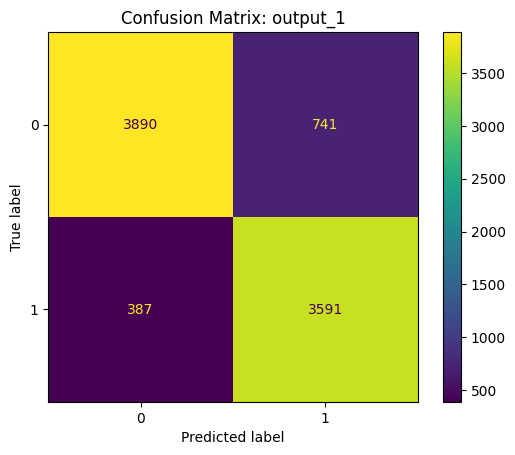

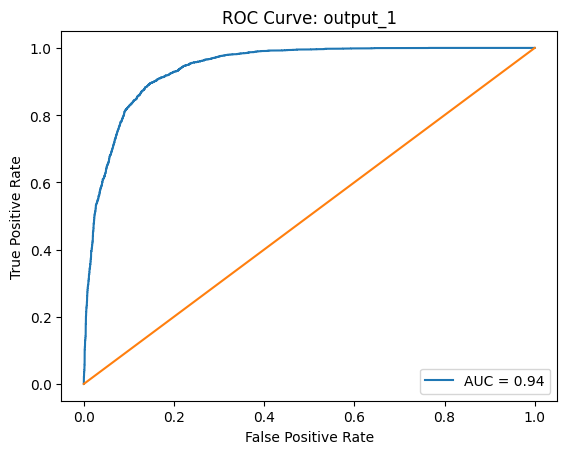

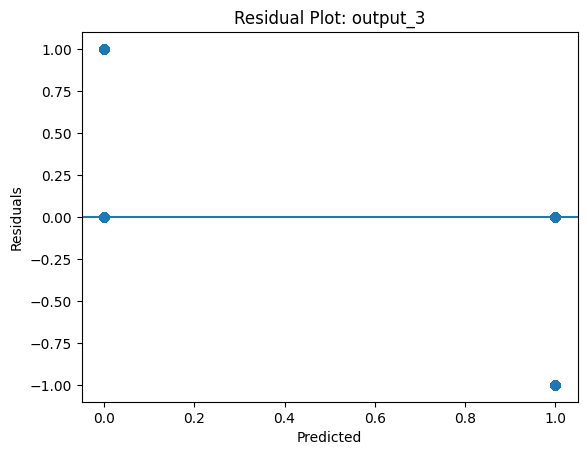

In [45]:
import matplotlib.pyplot as plt
import numpy as np

for col in ["output_2", "output_3"]:
    y_true = output_test[col].values
    y_pred = predictors[col].predict(input_test)

    plt.figure()
    plt.scatter(y_true, y_pred)
    
    # ideal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Regression Plot: {col}")
    plt.show()


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = output_test["output_1"]
y_pred = predictors["output_1"].predict(input_test)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Confusion Matrix: output_1")
plt.show()

from sklearn.metrics import roc_curve, auc

y_true = output_test["output_1"]
y_proba = predictors["output_1"].predict_proba(input_test)[1]  # prob of class 1

fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1])  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: output_1")
plt.legend()
plt.show()



residuals = y_true - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title(f"Residual Plot: {col}")
plt.show()